In [74]:
import tkinter as tk
from PIL import Image, ImageDraw
import numpy as np

class AplicacionDibujo:
    def __init__(self, master, ancho=500, alto=500):
        self.master = master
        self.master.title("Escoge tu edad")
        self.master.config(padx=10, pady=10)
        
        self.ancho = ancho
        self.alto = alto
        self.color_actual = "black"
        self.grosor = 5
        
        # 1. Crear la imagen en memoria (Pillow) donde guardaremos los datos reales
        self.imagen_pil = Image.new("RGB", (self.ancho, self.alto), "white")
        self.dibujo_pil = ImageDraw.Draw(self.imagen_pil)
        
        # 2. Crear la interfaz gráfica (Tkinter)
        frame_herramientas = tk.Frame(self.master, width=150)
        frame_herramientas.pack(side="left", fill="y", padx=(0, 10))

        self.canvas = tk.Canvas(self.master, width=self.ancho, height=self.alto, bg="white", cursor="none")
        self.canvas.pack(side="right")
        
        self.puntero_visual = self.canvas.create_oval(0, 0, 0, 0, outline="black", width=1)

        self.canvas.bind("<B1-Motion>", self.dibujar) 
        # 2. Cuando soltamos el botón (ya existía)
        self.canvas.bind("<ButtonRelease-1>", self.resetear_coordenadas)
        
        # 3. NUEVO: Cuando movemos el ratón SIN PINTAR (solo flotando)
        # Necesitamos esto para que el círculo nos siga siempre.
        self.canvas.bind("<Motion>", self.actualizar_puntero_visual)
        
        # 4. NUEVO: Asegurar que el círculo desaparezca si salimos del lienzo
        self.canvas.bind("<Leave>", self.ocultar_puntero_visual)
        
        self.x_anterior = None
        self.y_anterior = None
        
        # 3. Panel de herramientas (Botones)
        tk.Label(frame_herramientas, text="Colores", font=("Arial", 10, "bold")).pack(pady=(0, 5))

        frame_paleta = tk.Frame(frame_herramientas)
        frame_paleta.pack(pady=5)
        
        colores = [
            "#000000", "#7F7F7F", "#FFFFFF",  
            "#ED1C24", "#FF7F27", "#FFF200", 
            "#22B14C", "#00A2E8", "#3F48CC", 
            "#A349A4", "#FFAEC9", "#880015"
        ]
        fila = 0
        columna = 0
        for color in colores:
            btn = tk.Button(frame_paleta, bg=color, width=3, height=1,
                            command=lambda c=color: self.cambiar_color(c))
            btn.grid(row=fila, column=columna, padx=2, pady=2)
            columna += 1
            if columna > 2: # 3 colores por fila
                columna = 0
                fila += 1
        

        tk.Label(frame_herramientas, text="Grosor", font=("Arial", 10, "bold")).pack(pady=(15, 0))
        
        self.tamanos_pincel = [2, 5, 10, 15, 25]
        
        # Etiqueta para el texto (ej. "10 px")
        self.label_grosor = tk.Label(frame_herramientas, text="")
        self.label_grosor.pack()
        
        # Pequeño recuadro para ver el punto del pincel
        self.canvas_muestra = tk.Canvas(frame_herramientas, width=40, height=40, bg="white", 
                                        highlightthickness=1, highlightbackground="lightgray")
        self.canvas_muestra.pack(pady=5)
        # Creamos un óvalo vacío por ahora
        self.id_circulo = self.canvas_muestra.create_oval(0, 0, 0, 0, fill=self.color_actual)

        # El deslizador
        self.slider_grosor = tk.Scale(frame_herramientas, from_=0, to=4, orient="horizontal",
                                      showvalue=False, command=self.cambiar_grosor)
        self.slider_grosor.pack(fill="x", padx=10, pady=5)
        
        # Le damos el valor inicial (esto actualizará el texto y el círculo automáticamente)
        self.slider_grosor.set(2)
        

        tk.Label(frame_herramientas, text="Acciones", font=("Arial", 10, "bold")).pack(pady=(15, 5))

        btn_goma = tk.Button(frame_herramientas, text="Goma", width=10, 
                            command=self.borrar)
        btn_goma.pack(pady=2)

        btn_limpiar = tk.Button(frame_herramientas, text="Limpiar Todo", width=15,
                                command=self.limpiar_lienzo)
        btn_limpiar.pack(pady=2)

        tk.Frame(frame_herramientas, height=2, bg="gray").pack(fill="x", pady=15)

        btn_terminar = tk.Button(frame_herramientas, text="Guardar", width=15,
                                 bg="green", fg="white", font=("Arial", 10, "bold"),
                                 command=self.terminar)
        btn_terminar.pack(side="bottom", pady=5)
        
        # Variable para almacenar el resultado final
        self.imagen_resultado = None

    def cambiar_color(self, nuevo_color):
        self.color_actual = nuevo_color
        # Actualizamos el color del círculo de muestra
        self.canvas_muestra.itemconfig(self.id_circulo, fill=self.color_actual)
    
    def cambiar_grosor(self, indice):
        posicion = int(indice)
        self.grosor = self.tamanos_pincel[posicion]
        
        # 1. Actualizar el texto
        self.label_grosor.config(text=f"{self.grosor} px")
        
        # 2. Actualizar el tamaño del círculo de muestra
        centro = 20 # La mitad de nuestro canvas_muestra que mide 40x40
        radio = self.grosor / 2
        self.canvas_muestra.coords(self.id_circulo, 
                                   centro - radio, centro - radio, 
                                   centro + radio, centro + radio)

    def dibujar(self, evento):
        # ... (todo tu código actual de dibujar líneas aquí) ...
        if self.x_anterior and self.y_anterior:
            self.canvas.create_line(self.x_anterior, self.y_anterior, evento.x, evento.y, 
                                    width=self.grosor, fill=self.color_actual, 
                                    capstyle=tk.ROUND, smooth=tk.TRUE)
            # Dibujar en Pillow...
            self.dibujo_pil.line([self.x_anterior, self.y_anterior, evento.x, evento.y], 
                                 fill=self.color_actual, width=self.grosor)
            
        self.x_anterior = evento.x
        self.y_anterior = evento.y

        # --- NUEVO: Llamamos a actualizar el puntero también mientras pintamos ---
        self.actualizar_puntero_visual(evento)
            
        self.x_anterior = evento.x
        self.y_anterior = evento.y
    
    def borrar(self):
        self.color_actual = "white"

    def limpiar_lienzo(self):
        # Borramos el lienzo de Tkinter
        self.canvas.delete("all")
        # Borramos la imagen de Pillow dibujando un rectángulo blanco gigante
        self.dibujo_pil.rectangle([0, 0, self.ancho, self.alto], fill="white")
        self.puntero_visual = self.canvas.create_oval(0, 0, 0, 0, outline="black", width=1)

    def actualizar_puntero_visual(self, evento):
        """Mueve el círculo gris para que siga al ratón y tenga el tamaño correcto."""
        radio = self.grosor / 2
        
        # Calculamos las coordenadas del círculo centradas en el ratón
        x1 = evento.x - radio
        y1 = evento.y - radio
        x2 = evento.x + radio
        y2 = evento.y + radio
        
        # Movemos el objeto existente en el canvas
        self.canvas.coords(self.puntero_visual, x1, y1, x2, y2)
        
        # IMPORTANTE: Nos aseguramos de que el puntero esté SIEMPRE 
        # por encima de cualquier línea que acabemos de dibujar.
        self.canvas.tag_raise(self.puntero_visual)

    def ocultar_puntero_visual(self, evento):
        """Oculta el círculo si el ratón sale del Canvas."""
        self.canvas.coords(self.puntero_visual, 0, 0, 0, 0)

    def resetear_coordenadas(self, evento):
        self.x_anterior = None
        self.y_anterior = None

    def terminar(self):
        # Convertir la imagen de Pillow a un array de NumPy (ideal para procesar)
        self.imagen_resultado = np.array(self.imagen_pil)
        # Cerrar la ventana
        self.master.destroy()

def procesar_imagen(imagen_array):
    print("\n--- Procesando Imagen ---")
    print(f"Tipo de dato: {type(imagen_array)}")
    print(f"Dimensiones de la imagen (Alto, Ancho, Canales RGB): {imagen_array.shape}")

def main():
    # Inicializar Tkinter
    root = tk.Tk()
    app = AplicacionDibujo(root)
    
    # Iniciar el bucle de la ventana (el código se detiene aquí hasta que se cierre la ventana)
    root.mainloop()
    
    # Una vez cerrada la ventana, comprobamos si hay un resultado y lo pasamos a la otra función
    if app.imagen_resultado is not None:
        procesar_imagen(app.imagen_resultado)
        return app.imagen_resultado
    else:
        print("La ventana se cerró sin guardar la imagen.")

In [75]:
img = main()


--- Procesando Imagen ---
Tipo de dato: <class 'numpy.ndarray'>
Dimensiones de la imagen (Alto, Ancho, Canales RGB): (500, 500, 3)


Normalizamos la imagen (dividiendo entre $255$) e invertimos sus colores (para que el fondo sea negro y, por tanto, la matriz sparse).

In [25]:
img_norm = 1 - img/255


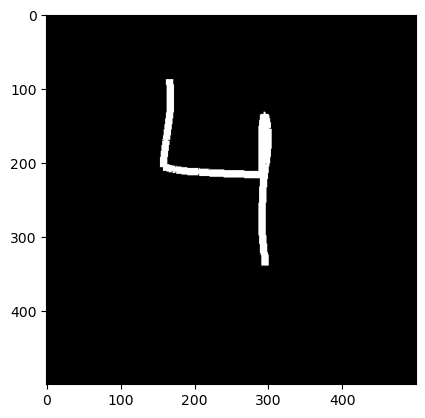

In [26]:
import matplotlib.pyplot as plt
plt.imshow(img_norm)

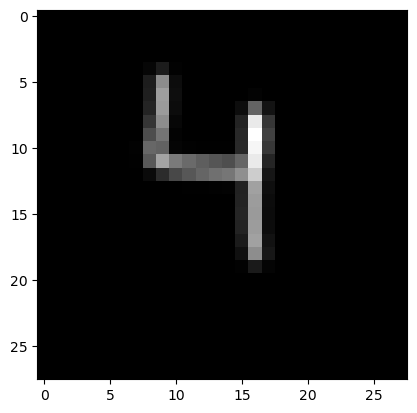

In [27]:
from skimage.transform import resize
resized_img = resize(img_norm, (28, 28))
resized_img = resized_img/resized_img.max()
plt.imshow(resized_img, cmap = "gray")

In [28]:
import tensorflow as tf
modelo = tf.keras.models.load_model('modelos/CNN_edad.keras')

Como nuestra imagen es en blanco y negro, nos quedamos con solo uno de los $3$ canales (la información está repetida).

In [29]:
edad = resized_img[:,:,0].reshape(1, 28, 28, 1)
pred = modelo.predict(edad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


In [30]:
print("La edad del niño es:", np.argmax(pred))

La edad del niño es: 4


---

In [ ]:
# pip install opencv-python numpy

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ----------- ---------------------------- 12.1/40.2 MB 66.8 MB/s eta 0:00:01
   -------------------------- ------------- 26.2/40.2 MB 66.2 MB/s eta 0:00:01
   ---------------------------------------  39.3/40.2 MB 64.2 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 60.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [31]:
import cv2
import numpy as np

In [ ]:
imagen = 255 - img

contornos, _ = cv2.findContours(imagen[:,:,0], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [98]:
cv2.boundingRect(contornos[0])

(88, 94, 68, 237)

In [99]:
cajas_delimitadoras = []
for c in contornos:
    x, y, w, h = cv2.boundingRect(c)
    
    if w > 10 and h > 10: # Filtramos contornos peuqeños, posiblemente ruido o manchas accidentales al dibujar
        cajas_delimitadoras.append((x, y, w, h))

In [107]:
cajas_delimitadoras = sorted(cajas_delimitadoras, key = lambda v: v[0])

In [ ]:
digitos = []

for (x, y, w, h) in cajas_delimitadoras:
        # Recortar el dígito de la imagen original
        recorte = imagen[:,:,0][y:y+h, x:x+w]